In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)

/tmp/dcs-tmp.u1604520/ipykernel_619993/1332554494.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [27]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/paper_bas/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/anti_{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/symmetric_{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/kl_pp")
# experiment_dir = Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_pp")
experiment_dir = Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_mvn_different_n")

# assert experiment_dir.exists()
# all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
# all_results_df = all_results_df.loc[(all_results_df["num_test_observations"] == 50) & (all_results_df["num_observations"] == 100)]
# all_results_df

df_list = []
for name in ["normal", "trunc", "mvn"]:
    df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_{name}_different_n/results.csv")))
df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_pp/results.csv")))
df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_mvn_n20/results.csv")))
df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/kl_exp/results.csv")))
all_results_df = pd.concat(df_list)
all_results_df = all_results_df.loc[(all_results_df["num_test_observations"] == 50) & (all_results_df["num_observations"] == 20) ]  # filter number of observations
# all_results_df = all_results_df.loc[(all_results_df["num_test_observations"] == 50)]  # filter number of observations

In [34]:
filter_dgp = "exponential"  # filter by DGP
results_df = preprocess_results_df(all_results_df, filter_dgp)
results_df.head(3)


,uuid,replication,solution,dgp_time,likelihood_time,posterior_time,solve_time,setup_time,log_partition_constant,out_of_sample_cost,...,num_likelihood_samples,num_observations,num_posterior_samples,num_replications,num_test_observations,posterior,num_total_samples,sample_time,in_group_mean,in_group_var
14000,1e18004d-4b77-4cd6-8338-73891d88d9ca,0,[74.06169511151866],0.000339,0.001742,0.000031,0.134024,NaN,0.0,"[219.9648334074147, 214.0652366015235, 160.373...",...,25,20,1,500,50,gamma,25,0.001773,168.354709,2226.340234
14001,1e18004d-4b77-4cd6-8338-73891d88d9ca,1,[22.71624288155898],0.000238,0.000093,0.000019,0.027775,NaN,0.0,"[1.2778676062903571, 14.221687285391177, 272.6...",...,25,20,1,500,50,gamma,25,0.000112,103.483832,38143.380746
14002,1e18004d-4b77-4cd6-8338-73891d88d9ca,2,[24.34646826063697],0.000225,0.000092,0.000019,0.026470,NaN,0.0,"[67.77405580842131, 35.673127091392544, 99.852...",...,25,20,1,500,50,gamma,25,0.000111,59.794975,4353.953379


In [12]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples", "num_observations"])
agg_df

/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7f5f2c3028e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function std at 0x7f5f2c302a20> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm dgp                 epsilon num_total_samples num_observations                       
kl_bdro   multivariate_normal 0.001   25                5                         274.912913   
                                                        20                        145.334627   
                                                        100                       103.970322   
                                      100               5                         258.036059   
                                                        20                        121.968694   
...                                                                                      ...   
kl_pp     multivariate_normal 3.000   100               20                        174.340858   
                                                        100                       135.433620   
                                      900               5                         381.808852   
                                                        20                        234.518587   
                                                        100                       159.230942   

                                                                          out_of_sample_var  \
algorithm dgp                 epsilon num_total_samples num_observations                      
kl_bdro   multivariate_normal 0.001   25                5                      27955.111816   
                                                        20                      8921.241281   
                                                        100                     3051.916647   
                                      100               5                      17870.169346   
                                                        20                      5886.326720   
...                                                                                     ...   
kl_pp     multivariate_normal 3.000   100               20                      7124.531538   
                                                        100                     3374.098696   
                                      900               5                      63586.780352   
                                                        20                      9294.356116   
                                                        100                     2983.214982   

                                                                          sum_of_in_group_var  \
algorithm dgp                 epsilon num_total_samples num_observations                        
kl_bdro   multivariate_normal 0.001   25                5                         8607.159399   
                                                        20                        5130.838877   
                                                        100                       2871.574058   
                                      100               5                         9115.911018   
                                                        20                        5051.357831   
...                                                                                       ...   
kl_pp     multivariate_normal 3.000   100               20                        2450.672940   
                                                        100                       2342.582057   
                                      900               5                         2136.835949   
                                                        20                        2101.329878   
                                                        100                       2236.827861   

                                                                          var_of_in_group_mean  \
algorithm dgp                 epsilon num_total_samples num_observations                         
kl_bdro   multivariate_normal 0.001   25                5                         19347.952417   
                                 

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

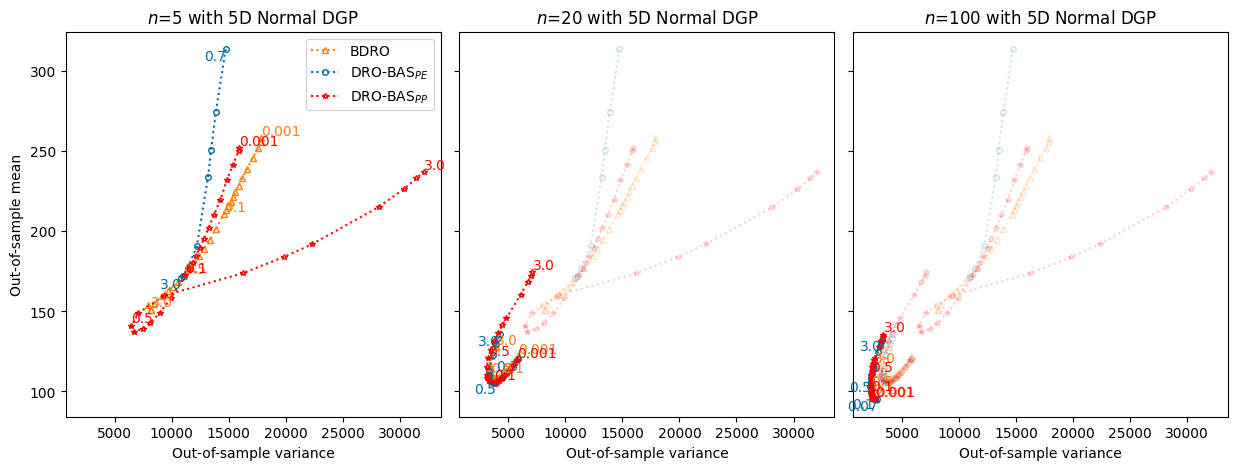

In [14]:
# total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
num_observations_list = agg_df.index.get_level_values("num_observations").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
# ncols = len(total_samples_list)
ncols = len(num_observations_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)
total_samples = 100
for i, dgp in enumerate(dgp_list):
    # for j, total_samples in enumerate(total_samples_list):
    for j, num_observations in enumerate(num_observations_list):
        axis_df = agg_df.loc[:, dgp, :, total_samples, num_observations] #
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            # for k in range(j, len(total_samples_list)):
            for k in range(j, len(num_observations_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend()
            axes[j].set_ylabel("Out-of-sample mean")
        # axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

Plot for all DGPs

/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7f5f2c3028e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function std at 0x7f5f2c302a20> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7f5f2c3028e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: Futur

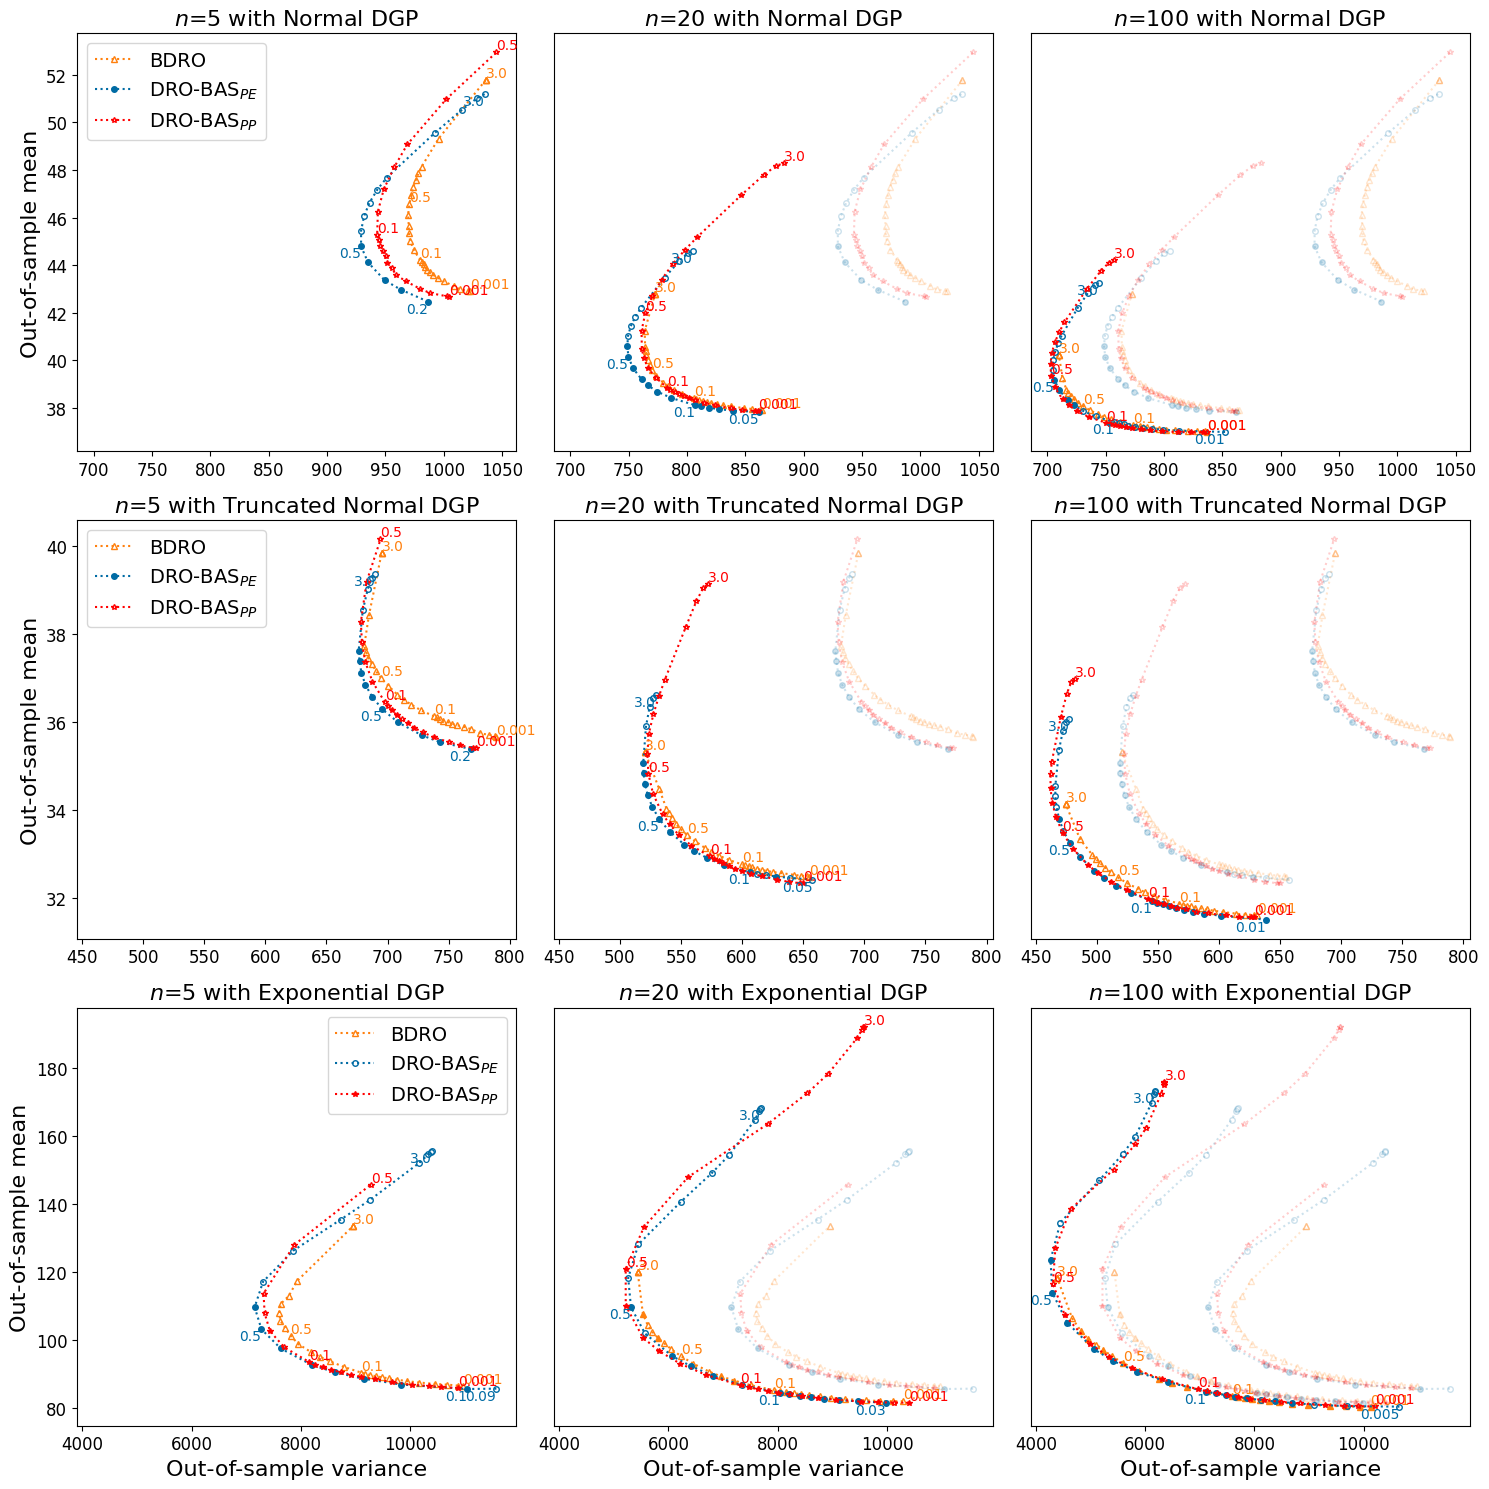

In [26]:
dgp_list = ['normal', 'truncated_normal',  'exponential'] #multivariate_normal
# total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
num_observations_list = agg_df.index.get_level_values("num_observations").unique().tolist()
nrows = len(dgp_list)
# ncols = len(total_samples_list)
ncols = len(num_observations_list)
trim_epsilon = 1.0
total_samples = 100
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'

for i in range(nrows):
    for j in range(1, ncols):
        axes[i, j].sharex(axes[i, 0])
        axes[i, j].sharey(axes[i, 0])

        
for i, dgp in enumerate(dgp_list):
    results_df = preprocess_results_df(all_results_df, dgp)
    agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples", "num_observations"])
    # for j, total_samples in enumerate(total_samples_list):
    for j, num_observations in enumerate(num_observations_list):
        axis_df = agg_df.loc[:, dgp, :, total_samples, num_observations] #
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            if (num_observations == 5) and (algorithm == 'kl_pp'):
                df = df[df.index < 0.6]
            # for k in range(j, len(total_samples_list)):
            for k in range(j, len(num_observations_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[i,k], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)

        if j == 0:
            axes[i,j].legend(fontsize=14)
            axes[i,j].set_ylabel("Out-of-sample mean", fontsize=16)
            
        # axes[i,j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[dgp]}", fontsize=16)
        axes[i, j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[dgp]}", fontsize=16)
        if i == 2:
            axes[i,j].set_xlabel("Out-of-sample variance", fontsize=16)
        axes[i,j].tick_params(axis='both', which='major', labelsize=12)

for i in range(nrows):  # Loop over rows
    for j in range(1, ncols):  # Start from the second column
        axes[i, j].tick_params(left=False, labelleft=False)  # Turn off ticks and labels

# Ensure the first column retains its ticks and labels
for i in range(nrows):
    axes[i, 0].tick_params(left=True, labelleft=True, labelsize=12)  # Explicitly enable ticks and labels

plt.tight_layout()
plt.show()

# Plot sum of in-group variance and variance of in-group mean
Let $m$ be the number of test observations.
Let $k$ be the number of replications.
Let $\xi_{ij}$ be the $i^{\text{th}}$ test observation for replication $j$.
For a given replication $j$, the in-group mean and variance is
$$\mu_j = \frac{1}{m}\sum_{i=1}^m f(x_j, \xi_{ij}), \hspace{2em} v_j = \frac{1}{m-1}\sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \mu_j \right)^2$$

We define the mean across all replications and all test observations as
$$\bar{\mu} = \frac{1}{mk} \sum_{j=1}^k \sum_{i=1}^m f(x_j, \xi_{ij}).$$

The total variance is defined by $$\frac{1}{mk-1}\sum_{j=1}^k \sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \bar{\mu} \right)^2.$$
This can be decomposed into two terms.
The first is a constant times the sum of the in-group variances:
$$\frac{m-1}{km - 1} \sum^k_{j=1} v_j,$$
and the second term is a constant times the variance of the in-group means:
$$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j).$$


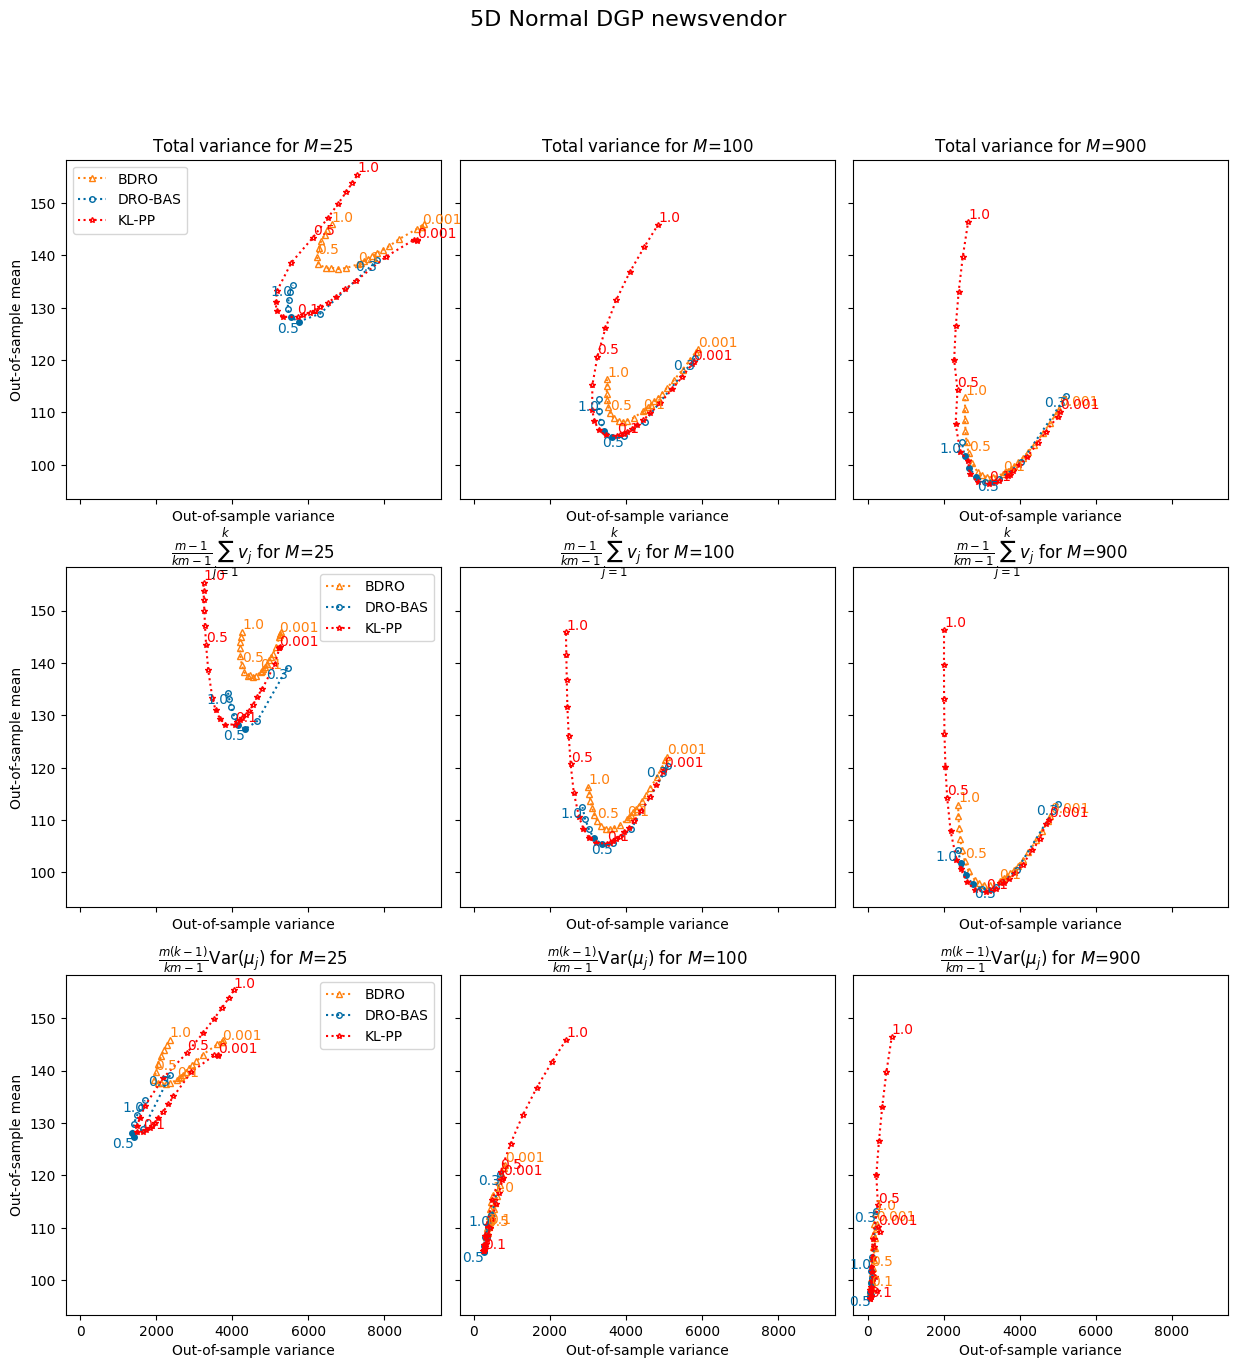

In [32]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = 3
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
fig.suptitle(f"{NiceNameDGP[filter_dgp]} newsvendor", fontsize=16)

nice_var_names = {
    "out_of_sample_var": "Total variance",
    "sum_of_in_group_var": r"$\frac{m-1}{km - 1} \sum^k_{j=1} v_j$",
    "var_of_in_group_mean": r"$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j)$",
}

for i, var_col in enumerate(["out_of_sample_var", "sum_of_in_group_var", "var_of_in_group_mean"]):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :trim_epsilon, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i][j], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, var_col=var_col)
        if j == 0:
            axes[i][j].legend()
            axes[i][j].set_ylabel("Out-of-sample mean")
        axes[i][j].set_title(nice_var_names[var_col] + " for $M$" + f"={total_samples}")
        axes[i][j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

## Solve & sampling time

In [21]:
solve_time_df

out_of_sample_mean  out_of_sample_var  \
algorithm  num_total_samples                                          
kl_bdro    25                           140.8383          7171.7718   
           100                          115.0709          4365.8633   
           900                          107.9092          3623.2292   
kl_dro_bas 25                           135.0397          6169.0043   
           100                          116.5268          4047.6155   
           900                          113.7309          3543.9582   

                              sum_of_in_group_var  var_of_in_group_mean  \
algorithm  num_total_samples                                              
kl_bdro    25                         128456.0957             2579.3463   
           100                        105764.0870              587.6074   
           900                         91744.3355              346.1167   
kl_dro_bas 25                          50458.2391             1960.7753   
           100                         38797.9720              813.1059   
           900                         34199.4155              692.8640   

                              mean_solve_time  std_solve_time  \
algorithm  num_total_samples                                    
kl_bdro    25                          0.0762          0.0128   
           100                         0.1821          0.0219   
           900                         1.1183          0.0892   
kl_dro_bas 25                          0.0300          0.0038   
           100                         0.0768          0.0081   
           900                         0.9509          0.0941   

                              mean_sample_time  std_sample_time  \
algorithm  num_total_samples                                      
kl_bdro    25                           0.0032           0.0002   
           100                          0.0058           0.0002   
           900                          0.0163           0.0005   
kl_dro_bas 25                           0.0004           0.0000   
           100                          0.0004           0.0000   
           900                          0.0005           0.0000   

                               str_solve_time  str_sample_time  
algorithm  num_total_samples                                    
kl_bdro    25                 0.0762 (0.0128)  0.0032 (0.0002)  
           100                0.1821 (0.0219)  0.0058 (0.0002)  
           900                1.1183 (0.0892)  0.0163 (0.0005)  
kl_dro_bas 25                   0.03 (0.0038)     0.0004 (0.0)  
           100                0.0768 (0.0081)     0.0004 (0.0)  
           900                0.9509 (0.0941)     0.0005 (0.0)

In [35]:
solve_time_df = get_agg_df(results_df, ["algorithm", "num_total_samples"])
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").to_latex())

\begin{tabular}{lllllll}
\toprule
 & \multicolumn{3}{r}{str_solve_time} & \multicolumn{3}{r}{str_sample_time} \\
algorithm & kl_bdro & kl_dro_bas & kl_pp & kl_bdro & kl_dro_bas & kl_pp \\
num_total_samples &  &  &  &  &  &  \\
\midrule
25 & 0.0655 (0.0122) & 0.0234 (0.0036) & 0.0238 (0.0068) & 0.0004 (0.0) & 0.0001 (0.0) & 0.0001 (0.0001) \\
100 & 0.1438 (0.0201) & 0.0356 (0.0039) & 0.0365 (0.0041) & 0.0006 (0.0) & 0.0001 (0.0) & 0.0001 (0.0) \\
900 & 0.7227 (0.0438) & 0.4445 (0.0311) & 0.4511 (0.0317) & 0.0016 (0.0001) & 0.0001 (0.0) & 0.0002 (0.0) \\
\bottomrule
\end{tabular}



/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7f5f2c3028e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function std at 0x7f5f2c302a20> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


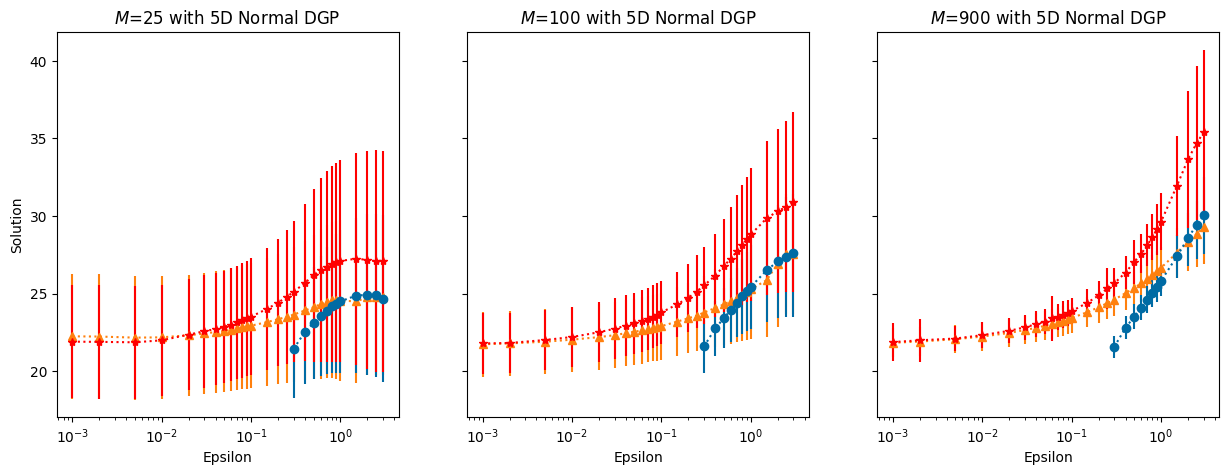

In [34]:
df = results_df.copy()
df["solution"] = df["solution"].map(lambda x: x[4])
nrows = len(dgp_list)
ncols = len(total_samples_list)
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
solution_df = df.groupby(["algorithm", "dgp", "epsilon", "num_total_samples"]).agg({"solution": ["mean", "std"]})
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = solution_df.loc[:, dgp, :, total_samples]
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            axes[j].errorbar(axis_df.loc[algorithm, :].index.get_level_values("epsilon"), axis_df.loc[algorithm, :]["solution"]["mean"], yerr=axis_df.loc[algorithm, :]["solution"]["std"], **algorithm_inference_style(algorithm, "bayes"))
        axes[j].set_xscale("log")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Epsilon")
        if j == 0:
            axes[j].set_ylabel("Solution")